In [1]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
import numpy as np

In [2]:
model = LogisticRegression(penalty='l1')
'''1) penalty: Literal['l1', 'l2', 'elasticnet'] | None = "l2",
   model = LogisticRegression(penalty='l1')
   model = LogisticRegression(penalty='l2')
   model = LogisticRegression(penalty='elasticnet)
   
   2) solver: Literal['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'] = "lbfgs",
    max_iter: Int = 100,
    solver : It is an optimization engine which helps gradient descent to optimize the weights
    
    solver	                penalty	                        multinomial multiclass
    'lbfgs'	                'l2', None	                    yes
    'liblinear'	            'l1', 'l2'	                    no
    'newton-cg'	            'l2', None	                    yes
    'newton-cholesky'	    'l2', None	                    yes
    'sag'	                'l2', None	                    yes
    'saga'	                'elasticnet','l1','l2',None	    yes
    
    3) max_iter : maximum number of iterations
        max iter = Int=100
    * Gradient desect stops iteration by using tolerance
    
    4)class_weight = None|'balanced'
      why class_weight ? -> for imbalanced dataset
       how to find the datset is balanced or not -> by using [count_values] ( unique value counts in target column)
      how to handle Imbalanced dataset?
         1. class_weight
         2.  Re_sampling
'''


'1) penalty: Literal[\'l1\', \'l2\', \'elasticnet\'] | None = "l2",\n   model = LogisticRegression(penalty=\'l1\')\n   model = LogisticRegression(penalty=\'l2\')\n   model = LogisticRegression(penalty=\'elasticnet)\n   \n   2) solver: Literal[\'lbfgs\', \'liblinear\', \'newton-cg\', \'newton-cholesky\', \'sag\', \'saga\'] = "lbfgs",\n    max_iter: Int = 100,\n    solver : It is an optimization engine which helps gradient descent to optimize the weights\n    \n    solver\t                penalty\t                        multinomial multiclass\n    \'lbfgs\'\t                \'l2\', None\t                    yes\n    \'liblinear\'\t            \'l1\', \'l2\'\t                    no\n    \'newton-cg\'\t            \'l2\', None\t                    yes\n    \'newton-cholesky\'\t    \'l2\', None\t                    yes\n    \'sag\'\t                \'l2\', None\t                    yes\n    \'saga\'\t                \'elasticnet\',\'l1\',\'l2\',None\t    yes\n    \n    3) max_iter : maximu

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')
df

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No
...,...,...,...,...,...,...,...,...,...
995,22,49241,500,41020,24 months,Self-Employed,Owned,No,Yes
996,40,116214,423,12415,48 months,Self-Employed,Owned,No,Yes
997,27,64569,300,28155,36 months,Self-Employed,Rented,Yes,Yes
998,61,31745,490,48884,12 months,Self-Employed,Mortgage,No,Yes


In [4]:
X = df.drop(columns='Loan_Approved')
y= df['Loan_Approved']

### Selecting numeric col and obj only

In [5]:
num_cols=X.select_dtypes(include='number').columns
obj_cols=X.select_dtypes(include='object').columns


In [6]:
num_cols

Index(['Age', 'Salary', 'Credit_Score', 'Loan_Amount'], dtype='object')

In [7]:
obj_cols

Index(['Loan_Term', 'Employment_Status', 'Residence_Type', 'Previous_Default'], dtype='object')

In [8]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

Finding Correlation between Feature columns

In [9]:
X.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


<Axes: >

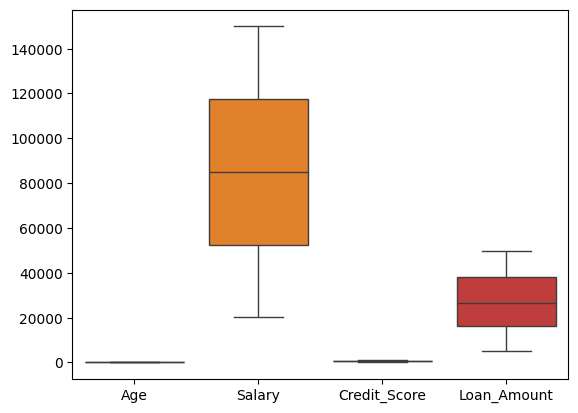

In [10]:
sns.boxplot(X[num_cols])

### Based on the uotliers we can decide te scaling technique

In [11]:
xtrain[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

* Preprocessing Techniques 
1. Scaling
2. Encoding

##### Why Scaling?
* Features(numeric) column values are in diff range(scale). So we cna use scaling to give  equal importance for all the feature cols


##### Why Encoding?
* Algorithms can understand only numbers not strings

##### Which Scaling ang Encoding Technique we can use for this?
* Scaling -> 1) MinMaxScaler ,2) 'StandardScaler'

* Encoding 
1. Loan_Term -4
2. employeement_status -3

In [12]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)
scaling = MinMaxScaler()
# model = LogisticRegression(penalty='l1',solver='liblinear')
model = LogisticRegression(penalty=None)

## Xtrian Update

In [13]:

xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
# xtrain[obj_cols] = encoder.fit_transform(xtrain[obj_cols]) 
#  here we get error bcz ValueError: Columns must be same length as key
encoded_values = encoder.fit_transform(xtrain[obj_cols])
encoded_columns = encoder.get_feature_names_out()

xtrain[encoded_columns] = encoded_values
xtrain.drop(columns=obj_cols,inplace=True)

In [14]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [15]:

xtest[num_cols] = scaling.transform(xtest[num_cols])
# xtrain[obj_cols] = encoder.fit_transform(xtrain[obj_cols]) 
#  here we get error bcz ValueError: Columns must be same length as key
encoded_values = encoder.transform(xtest[obj_cols])
encoded_columns = encoder.get_feature_names_out()

xtest[encoded_columns] = encoded_values
xtest.drop(columns=obj_cols,inplace=True)

In [16]:
model.fit(xtrain,ytrain)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
from sklearn.metrics import precision_score,confusion_matrix,f1_score,recall_score,accuracy_score

### Train data evaluation

In [18]:
ytrain_pred = model.predict(xtrain)
matrix = confusion_matrix(ytrain,ytrain_pred)

In [19]:
ytrain.value_counts()

Yes    403
No     397
Name: Loan_Approved, dtype: int64

#### Coclusion : half of te labels are correctly predicting remaining are not correctly predicted

In [20]:
precision_score(ytrain,ytrain_pred,pos_label='Yes')

0.5471698113207547

In [21]:
predicted_yes = np.sum(matrix[:,1])
predicted_yes#425
np.sum(matrix[:,0])

376

##### Conclusion : 
* out of all the predicted 'Yes' labels(425), 54% labels are correctly predicted as 'Yes'
* out of all the predicted 'Yes' labels(425), 46% labels are wrongly predicted as 'Yes'

In [22]:
precision_score(ytrain,ytrain_pred,pos_label='No')

0.5452127659574468

##### Conclusion : 
* out of all the predicted 'NO' labels(375), 54%labels are correctly predicted as 'N0'
* out of all the predicted 'No' labels(375), 46% labels are wrongly predicted as 'No'

In [23]:
recall_score(ytrain,ytrain_pred,pos_label='Yes')

0.575682382133995

##### Conclusion : 
* out of all the Actual 'Yes' labels(403), 57% labels are correctly predicted as 'Yes'
* out of all the Actual 'Yes' labels(403), 43% labels are wrongly predicted as 'Yes'

In [24]:
recall_score(ytrain,ytrain_pred,pos_label='No')

0.5163727959697733

##### Conclusion : 
* out of all the predicted 'NO' labels(397), 51%labels are correctly predicted as 'N0'
* out of all the predicted 'No' labels(397), 49% labels are wrongly predicted as 'No'

In [25]:
accuracy_score(ytrain,ytrain_pred)

0.54625

##### Conclusion:
* out of all the samples(800) 54.75% samples are correctly predicted

### Final Conclusion:
* Model performance on train data is bad, so model is not learned train data petterns properly

In [26]:
ytest_pred = model.predict(xtest)
accuracy_score(ytest,ytest_pred)

0.5

In [27]:
from sklearn.metrics import classification_report

In [28]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



macro : out of all the predicted values how many values are correctly predicted

In [29]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200

